# MI feature selection — beyond Pearson
[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/jejjohnson/rbig/blob/main/docs/notebooks/21_mi_feature_selection.ipynb)

`RBIGMISelector` ranks features by **mutual information** with the
target, estimated through RBIG. Unlike Pearson correlation, MI captures
*nonlinear* dependence — a feature that determines the target through a
U-shape has near-zero correlation but high MI.

> **Colab / fresh environment?** Run the cell below to install `rbig`.
> Skip if already installed.

In [ ]:
!pip install "rbig[all] @ git+https://github.com/jejjohnson/rbig.git" -q

In [2]:
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np

from rbig import RBIGMISelector

plt.style.use("seaborn-v0_8-paper")

/home/user/rbig/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Data: a nonlinear informative feature among noise

The target depends on `x0` through a **quadratic** (U-shaped)
relationship — zero linear correlation, strong dependence — plus a
linearly-informative `x1`, and three pure-noise features.

In [3]:
rng = np.random.default_rng(0)
n = 1500
x0 = rng.uniform(-2, 2, n)  # nonlinear-informative (U-shape)
x1 = rng.standard_normal(n)  # linear-informative
noise = rng.standard_normal((n, 3))
X = np.column_stack([x0, x1, noise])
y = x0**2 + 0.5 * x1 + 0.3 * rng.standard_normal(n)

## MI vs Pearson on each feature

Pearson misses `x0` entirely (its correlation with `y` is ~0 by
symmetry); RBIG-MI ranks it as informative.

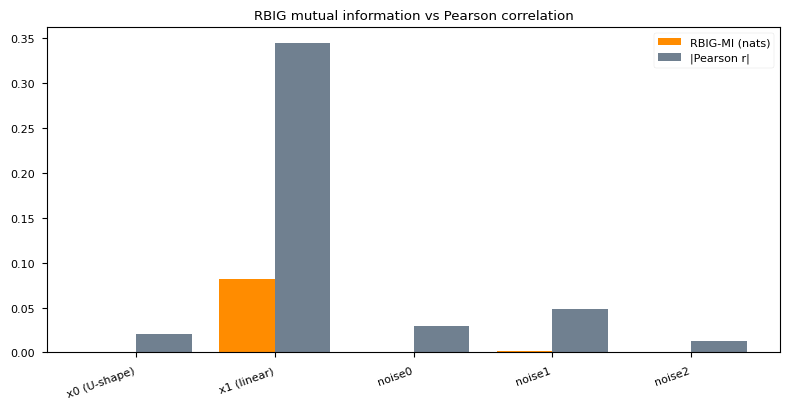

In [4]:
sel = RBIGMISelector(
    n_features_to_select=2, strategy="filter", n_layers_rbig=15, random_state=0
).fit(X, y)
pearson = np.array([abs(np.corrcoef(X[:, j], y)[0, 1]) for j in range(X.shape[1])])

names = ["x0 (U-shape)", "x1 (linear)", "noise0", "noise1", "noise2"]
idx = np.arange(len(names))
fig, ax = plt.subplots(figsize=(8, 4.2))
w = 0.4
ax.bar(idx - w / 2, sel.mi_scores_, w, label="RBIG-MI (nats)", color="darkorange")
ax.bar(idx + w / 2, pearson, w, label="|Pearson r|", color="slategray")
ax.set_xticks(idx)
ax.set_xticklabels(names, rotation=20, ha="right")
ax.set_title("RBIG mutual information vs Pearson correlation")
ax.legend()
plt.tight_layout()
plt.show()

## Selected features

In [5]:
print("MI scores:", np.round(sel.mi_scores_, 3))
print("|Pearson|:", np.round(pearson, 3))
print("selected feature indices:", sel.get_support(indices=True).tolist())

MI scores: [0.    0.081 0.    0.001 0.   ]
|Pearson|: [0.021 0.344 0.029 0.049 0.012]
selected feature indices: [1, 3]


## Takeaways

- MI ranks the **U-shaped** feature `x0` at the top where Pearson
  ranks it with the noise — the canonical reason to prefer an
  information criterion for selection.
- Strategies escalate in fidelity and cost: `filter` (univariate),
  `mrmr` (relevance − redundancy), `greedy` (conditional MI, captures
  synergy), `joint` (exhaustive). See the class docstring.
- **Honest limitation:** the RBIG MI estimator harvests only
  correlation-visible structure per rotation, so it is blind to pure
  XOR-style *synergy* (two features each independent of the target but
  jointly determining it). For that, a k-NN/KSG conditional-MI backend
  is the right tool.